In [ ]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

Plot time series of modelled vs observed hourly mean relative humidity averaged over the 8 DCCEEW stations - Figure S6

In [ ]:
#load obs data in the desired format

# Read the CSV file
df = pd.read_csv('/g/data/gb02/mf9078/RH-DCCEEW.csv')

# Combine Date and Time columns into a single datetime column
#df['Time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M')
df['Time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].astype(str), dayfirst=True)

# Drop the original Date and Time columns (optional)
df = df.drop(['Date'], axis=1)

# Reorder columns to put Time first
cols = ['Time'] + [col for col in df.columns if col != 'Time']
df = df[cols]

# Display basic information about the dataframe
print("DataFrame Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nLast few rows:")
print(df.tail())
print("\nBasic statistics:")
print(df.describe())

# Check for any missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Display the station columns
station_cols = ['RK', 'RE', 'LL', 'CA', 'ED', 'SS', 'PT', 'CN']
print(f"\nStation columns available: {station_cols}")
print(f"Total number of records: {len(df)}")
print(f"Date range: {df['Time'].min()} to {df['Time'].max()}")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Time    241 non-null    datetime64[ns]
 1   RK      241 non-null    float64       
 2   RE      241 non-null    float64       
 3   LL      241 non-null    float64       
 4   CA      241 non-null    float64       
 5   ED      241 non-null    float64       
 6   SS      241 non-null    float64       
 7   PT      240 non-null    float64       
 8   CN      241 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 17.1 KB
None

First few rows:
                 Time    RK    RE    LL    CA    ED    SS    PT    CN
0 2017-01-10 00:00:00  94.0  91.8  91.0  88.8  94.5  93.1  89.4  92.2
1 2017-01-10 01:00:00  91.7  91.3  92.1  88.9  94.5  94.0  86.0  94.2
2 2017-01-10 02:00:00  91.1  90.0  94.6  91.4  95.0  94.1  87.1  94.4
3 2017-01-10 03:00:00  91.5  89.1 

In [ ]:
#load WRF data
with open("/g/data/gb02/mf9078/WRF_Results-10-20Jan_avgDCCEEW_RH_mean.pkl", "rb") as f:
    average_rh = pickle.load(f)

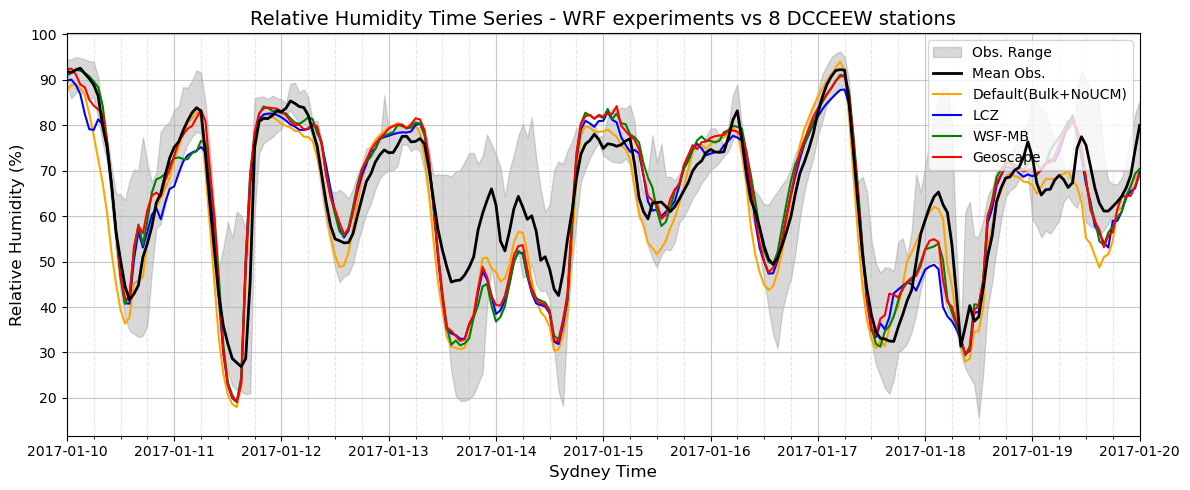

In [ ]:
#plot
line_colors = {
    'Default(Bulk+NoUCM)': 'orange',
    'LCZ': 'blue',
    'WSF-MB': 'green', 
    'Geoscape': 'red'
}

# Define station names
station_cols = ['RK', 'RE', 'LL', 'CA', 'ED', 'SS', 'PT', 'CN']
scenario = ['Default(Bulk+NoUCM)','LCZ', 'WSF-MB', 'Geoscape']

# Calculate the average, min, and max temperature across all stations
df['Average'] = df[station_cols].mean(axis=1)
df['Min'] = df[station_cols].min(axis=1)
df['Max'] = df[station_cols].max(axis=1)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 5))

# Plot the shaded area between min and max
ax.fill_between(df['Time'], df['Min'], df['Max'], 
                color='grey', alpha=0.3, label='Obs. Range')

# Plot the average temperature as a thick black line
ax.plot(df['Time'], df['Average'], label='Mean Obs.', linewidth=2, 
        color='black', linestyle='-', zorder=10)

# Plot individual station lines (lighter/thinner)
for sc in scenario:
    ax.plot(average_rh['time'], average_rh[sc], label=sc, color=line_colors[sc])

# Format the plot
ax.set_xlabel('Sydney Time', fontsize=12) #, fontweight='bold')
ax.set_ylabel('Relative Humidity (%)', fontsize=12) #, fontweight='bold')
ax.set_title('Relative Humidity Time Series - WRF experiments vs 8 DCCEEW stations', fontsize=14) #fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# Format x-axis to show dates nicely
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
#ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax.grid(True, which='minor', linestyle='--', alpha=0.3)  # 6-hourly
ax.grid(True, which='major', linestyle='-', alpha=0.7)   # daily

plt.xticks()
plt.xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))

# Tight layout to prevent label cutoff
plt.tight_layout()
plt.savefig("RH_Timeseries_8stations_DCCEEW.png", dpi=300)

# Display the plot
plt.show()
